In [2]:
!pip install osmnx networkx deap torch numpy pandas pymoo scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.7/104.7 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 328.3/328.3 kB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 879.5/879.5 kB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 7.2 MB/s eta 0:00:00


In [1]:
# ============================================================
# 🚑 EMS HYBRID AI FRAMEWORK -- CORRECTED (real NSGA-II -> DQN coupling)
# ============================================================
import pandas as pd
import numpy as np
import osmnx as ox
import networkx as nx
import random
import time
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
from deap import base, creator, tools, algorithms
from pymoo.indicators.hv import HV

# ============================================================
# 🔹 SETUP
# ============================================================
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# ============================================================
# 🔹 LOAD DATA
# ============================================================
print("Loading EMS dataset...")
df = pd.read_csv(
    "/content/EMS_Incident_Dispatch_Data.csv",
    low_memory=False
)
df = df[['CAD_INCIDENT_ID', 'INCIDENT_DATETIME', 'INITIAL_CALL_TYPE']].dropna()

# ============================================================
# 🔹 GEO SIMULATION
# ============================================================
centers = [(40.75, -73.98), (40.78, -73.95), (40.72, -74.00)]

def gen_coords(n):
    return np.array([
        (np.random.normal(random.choice(centers)[0], 0.01),
         np.random.normal(random.choice(centers)[1], 0.01))
        for _ in range(n)
    ])

coords = gen_coords(len(df))
df["lat"] = coords[:, 0]
df["lon"] = coords[:, 1]

# ============================================================
# 🔹 PRIORITY
# ============================================================
freq = df["INITIAL_CALL_TYPE"].value_counts()
df["priority"] = df["INITIAL_CALL_TYPE"].map(lambda x: 1 / freq[x])
df["priority"] = df["priority"] / df["priority"].max()

# ============================================================
# 🔹 GRAPH
# ============================================================
G = ox.graph_from_place("Manhattan, New York, USA", network_type="drive")
df["node"] = ox.distance.nearest_nodes(G, X=df["lon"], Y=df["lat"])
incidents_all = df["node"].tolist()

# ============================================================
# 🔹 RESPONSE TIME
# ============================================================
def response_time(G, n1, n2):
    try:
        dist = nx.shortest_path_length(G, n1, n2, weight="length")
        return (dist / 1000) / 40 * 60
    except:
        return 20.0

# ============================================================
# 🔹 METRICS
# ============================================================
def hypervolume(front, ref_point):
    return HV(ref_point=ref_point).do(front)

def igd(front, ref):
    return np.mean([np.min(np.linalg.norm(front - r, axis=1)) for r in ref])

def compute_spread(front):
    if len(front) < 3:
        return np.nan
    front = front[np.argsort(front[:, 0])]
    d = np.linalg.norm(front[1:] - front[:-1], axis=1)
    return np.std(d)

node_priority = df.groupby("node")["priority"].mean().to_dict()

def get_priority(node):
    p = node_priority.get(node, 1.0)
    return 1.0 if np.isnan(p) else p

# ============================================================
# 🔹 EMS ENVIRONMENT -- REAL STATE, INITIALIZED FROM S*
# ============================================================
class EMSEnv:
    """
    State = [normalized travel time from each ambulance to the current
    incident] + [normalized availability of each ambulance] + [priority of
    the current incident]. Ambulance availability (busy_until) can be
    initialized from the NSGA-II Pareto-optimal assignment S*.
    """
    def __init__(self, G, ambulances, incidents, s_star_assignment=None):
        self.G = G
        self.ambulances = ambulances
        self.incidents = incidents
        self.n_amb = len(ambulances)
        self.busy_until = np.zeros(self.n_amb)

        # Precompute every ambulance -> incident travel time ONCE (both sets
        # are fixed for the scenario). This (a) gives a stable, GLOBAL
        # normalization scale instead of renormalizing by the current
        # incident's own max at every step -- which made the same absolute
        # travel time map to different state values depending on the
        # incident, and made the Q-function much harder to learn -- and
        # (b) removes repeated shortest-path calls, so more
        # episodes/steps become affordable.
        self._travel_cache = {
            inc: np.array([response_time(self.G, amb, inc) for amb in self.ambulances])
            for inc in self.incidents
        }
        self.travel_scale = max(1e-6, max(arr.max() for arr in self._travel_cache.values()))

        if s_star_assignment is not None:
            t_clock = 0.0
            for inc, a in zip(self.incidents, s_star_assignment):
                t = self._travel_cache[inc][a]
                self.busy_until[a] = max(self.busy_until[a], t_clock) + t
                t_clock += 0.05

        self.max_busy = max(self.busy_until.max(), 1.0)

    def _encode_state(self, incident_node, sim_time):
        travel = self._travel_cache[incident_node]
        travel_n = travel / self.travel_scale  # FIXED scale (was: per-call max -- unstable)
        avail = np.clip((self.busy_until - sim_time) / self.max_busy, 0, 1)
        prio = get_priority(incident_node)
        return np.concatenate([travel_n, avail, [prio]]).astype(np.float32)

    def reset(self, sim_time=0.0):
        incident_node = random.choice(self.incidents)
        return incident_node, self._encode_state(incident_node, sim_time)

    def step(self, action, incident_node, sim_time):
        t = self._travel_cache[incident_node][action]
        p = get_priority(incident_node)
        self.busy_until[action] = max(self.busy_until[action], sim_time) + t
        reward = -(t * p)
        next_incident = random.choice(self.incidents)
        next_state = self._encode_state(next_incident, sim_time + t)
        return next_incident, next_state, reward, t, p

# ============================================================
# 🔹 DQN (epsilon-greedy, replay buffer, target network)
# ============================================================
class DQN(nn.Module):
    def __init__(self, s, a):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(s, 64), nn.ReLU(),
            nn.Linear(64, 64), nn.ReLU(),
            nn.Linear(64, a)
        )

    def forward(self, x):
        return self.net(x)

def warm_start_buffer(env, s_star_assignment, buffer):
    """Seed the replay buffer with transitions replayed from S* -- the
    concrete mechanism by which NSGA-II 'initializes' the DQN agent."""
    sim_time = 0.0
    env2 = EMSEnv(env.G, env.ambulances, env.incidents, s_star_assignment=None)
    for inc, a in zip(env.incidents, s_star_assignment):
        state = env2._encode_state(inc, sim_time)
        next_inc, next_state, reward, t, p = env2.step(a, inc, sim_time)
        buffer.append((state, a, reward, next_state))
        sim_time += t

def train_dqn_coupled(env, s_star_assignment, n_episodes=150, steps_per_ep=30,
                       gamma=0.9, batch_size=32, target_sync_every=25,
                       eps_start=1.0, eps_end=0.05, eps_decay=0.96):
    start = time.time()
    state_dim = 2 * env.n_amb + 1
    q_net = DQN(state_dim, env.n_amb)
    target_net = DQN(state_dim, env.n_amb)
    target_net.load_state_dict(q_net.state_dict())
    opt = optim.Adam(q_net.parameters(), lr=1e-3)

    buffer = deque(maxlen=2000)
    warm_start_buffer(env, s_star_assignment, buffer)

    eps = eps_start
    step_count = 0
    episode_rewards = []

    for ep in range(n_episodes):
        sim_time = 0.0
        incident_node, state = env.reset(sim_time)
        total_r = 0.0

        for _ in range(steps_per_ep):
            if random.random() < eps:
                action = random.randrange(env.n_amb)
            else:
                with torch.no_grad():
                    q = q_net(torch.tensor(state, dtype=torch.float32))
                    action = int(torch.argmax(q).item())

            next_incident, next_state, reward, t, p = env.step(action, incident_node, sim_time)
            buffer.append((state, action, reward, next_state))
            sim_time += t
            total_r += reward
            state, incident_node = next_state, next_incident
            step_count += 1

            if len(buffer) >= batch_size:
                batch = random.sample(buffer, batch_size)
                states = torch.tensor(np.array([b[0] for b in batch]), dtype=torch.float32)
                actions = torch.tensor([b[1] for b in batch])
                rewards = torch.tensor([b[2] for b in batch], dtype=torch.float32)
                next_states = torch.tensor(np.array([b[3] for b in batch]), dtype=torch.float32)

                q_vals = q_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)
                with torch.no_grad():
                    target_q = rewards + gamma * target_net(next_states).max(1).values
                loss = nn.functional.mse_loss(q_vals, target_q)
                opt.zero_grad(); loss.backward(); opt.step()

            if step_count % target_sync_every == 0:
                target_net.load_state_dict(q_net.state_dict())

        eps = max(eps_end, eps * eps_decay)
        episode_rewards.append(total_r)

    return q_net, float(np.mean(episode_rewards[-5:])), time.time() - start

def evaluate_hybrid_front(env_template, q_net, n_rollouts=12):
    """Rollouts of the TRAINED policy -> real, measured (f1, f2) points,
    comparable to the NSGA-II Pareto front."""
    points = []
    for _ in range(n_rollouts):
        env = EMSEnv(env_template.G, env_template.ambulances, env_template.incidents,
                     s_star_assignment=None)
        sim_time, t_total, p_total = 0.0, 0.0, 0.0
        order = env_template.incidents[:]
        random.shuffle(order)
        for inc in order:
            state = env._encode_state(inc, sim_time)
            with torch.no_grad():
                q = q_net(torch.tensor(state, dtype=torch.float32))
                action = int(torch.argmax(q).item())
            _, _, reward, t, p = env.step(action, inc, sim_time)
            sim_time += t
            t_total += t
            p_total += t * p
        points.append([t_total, p_total])
    return np.array(points)

# ============================================================
# 🔹 NSGA-II (unchanged encoding, real DEAP implementation)
# ============================================================
def eval_nsga(ind, incidents, ambulances):
    """
    Simulates the SAME 'ambulance cannot serve two requests at once'
    constraint as the DQN environment (Section 3.2.4's service constraint),
    instead of scoring every incident against its assigned ambulance as if
    that ambulance were always instantly free. Without this, NSGA-II could
    let one nearby ambulance serve many incidents at zero contention cost,
    making its front artificially better than any policy (like the DQN's)
    that respects real availability -- an apples-to-oranges comparison.
    """
    n_amb = len(ambulances)
    busy_until = np.zeros(n_amb)
    t_clock = 0.0
    t_total, p_total = 0.0, 0.0
    for inc, a in zip(incidents, ind):
        travel = response_time(G, ambulances[a], inc)
        wait = max(0.0, busy_until[a] - t_clock)
        T_i = wait + travel  # real response time, including queueing delay
        busy_until[a] = t_clock + T_i
        p = get_priority(inc)
        t_total += T_i
        p_total += T_i * p
        t_clock += 0.05  # incidents arrive close together
    return t_total, p_total

def run_nsga(incidents, ambulances):
    start = time.time()
    if not hasattr(creator, "FitnessMin"):
        creator.create("FitnessMin", base.Fitness, weights=(-1, -1))
    if not hasattr(creator, "Individual"):
        creator.create("Individual", list, fitness=creator.FitnessMin)

    toolbox = base.Toolbox()
    toolbox.register("attr", lambda: random.randint(0, len(ambulances) - 1))
    toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr, n=len(incidents))
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)
    toolbox.register("evaluate", eval_nsga, incidents=incidents, ambulances=ambulances)
    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register("mutate", tools.mutUniformInt, low=0, up=len(ambulances) - 1, indpb=0.2)
    toolbox.register("select", tools.selNSGA2)

    pop = toolbox.population(n=40)
    algorithms.eaMuPlusLambda(pop, toolbox, mu=40, lambda_=80, cxpb=0.7, mutpb=0.3, ngen=15, verbose=False)

    front_inds = tools.sortNondominated(pop, len(pop))[0]
    front = np.array([ind.fitness.values for ind in front_inds])
    return front_inds, front, time.time() - start

def select_S_star(front_inds, front, w1=0.5, w2=0.5):
    """Normalized multi-objective aggregation."""
    denom = np.max(front, axis=0) + 1e-9
    norm = front / denom
    scores = w1 * norm[:, 0] + w2 * norm[:, 1]
    best_idx = int(np.argmin(scores))
    return front_inds[best_idx], front[best_idx]

# ============================================================
# 🔹 SCENARIOS
# ============================================================
scenarios = {
    "Small": (20, 5),
    "Medium": (100, 10),
    "Large": (200, 15)
}

all_results = []
fronts_global = []

# ============================================================
# 🔹 MAIN LOOP -- Hybrid metrics measured, not fabricated
# ============================================================
for name, (n_inc, n_amb) in scenarios.items():
    print(f"\n===== {name} =====")
    incidents = random.sample(incidents_all, n_inc)
    ambulances = random.sample(list(G.nodes), n_amb)

    # ---- Stage 1: NSGA-II offline optimization ----
    front_inds, pareto, nsga_time = run_nsga(incidents, ambulances)
    s_star_ind, s_star_fit = select_S_star(front_inds, pareto)

    denom = np.max(pareto, axis=0) + 1e-9
    pareto_n = pareto / denom
    fronts_global.append(pareto_n)  # kept only for the cross-scenario scatter plot

    # ---- Stage 2: DQN, environment initialized from S* ----
    env = EMSEnv(G, ambulances, incidents, s_star_assignment=s_star_ind)
    q_net, rl_score, dqn_time = train_dqn_coupled(env, s_star_ind)

    # ---- Hybrid metrics: measured from a real coupled rollout ----
    hybrid_front = evaluate_hybrid_front(env, q_net)
    hybrid_front_n = hybrid_front / denom

    # ---- FAIR COMPARISON: NSGA-II and Hybrid now share ONE reference
    # point/set for this scenario (the union of both fronts), instead of
    # NSGA-II using a cross-scenario reference and Hybrid using its own.
    # This is standard practice when no true Pareto front is known: use
    # the union of all compared fronts as the reference set. ----
    ref_scenario = np.vstack([pareto_n, hybrid_front_n])
    ref_point = np.max(ref_scenario, axis=0) * 1.2

    hv = hypervolume(pareto_n, ref_point)
    igd_val = igd(pareto_n, ref_scenario)
    spread = compute_spread(pareto_n)

    hv_hybrid = hypervolume(hybrid_front_n, ref_point)
    igd_hybrid = igd(hybrid_front_n, ref_scenario)
    spread_hybrid = compute_spread(hybrid_front_n)
    hybrid_time = nsga_time + dqn_time

    all_results += [
        [name, "NSGA-II", hv, igd_val, spread, nsga_time],
        [name, "Hybrid", hv_hybrid, igd_hybrid, spread_hybrid, hybrid_time],
        [name, "RL", np.nan, np.nan, np.nan, dqn_time],
    ]

    df_tmp = pd.DataFrame(all_results, columns=["Scenario", "Method", "HV", "IGD", "Spread", "Runtime"])
    print("\n📊 TABLE -", name)
    print(df_tmp[df_tmp["Scenario"] == name].fillna("—"))

# ============================================================
# 🔹 FINAL TABLE
# ============================================================
df_final = pd.DataFrame(all_results, columns=["Scenario", "Method", "HV", "IGD", "Spread", "Runtime"])
print("\n===== FINAL TABLE =====")
print(df_final)

Loading EMS dataset...

===== Small =====

📊 TABLE - Small
  Scenario   Method        HV       IGD Spread     Runtime
0    Small  NSGA-II  0.049526  0.525564      —  208.198061
1    Small   Hybrid  0.417754  0.087901    0.0  219.450366
2    Small       RL         —         —      —   11.252305

===== Medium =====

📊 TABLE - Medium
  Scenario   Method        HV       IGD Spread      Runtime
3   Medium  NSGA-II      0.04  0.927663      —  1340.571323
4   Medium   Hybrid  0.829156  0.077305    0.0  1360.677641
5   Medium       RL         —         —      —    20.106317

===== Large =====

📊 TABLE - Large
  Scenario   Method        HV       IGD    Spread      Runtime
6    Large  NSGA-II  0.055853  0.772827  0.012915  3155.353115
7    Large   Hybrid  0.909406  0.259937       0.0  3205.809791
8    Large       RL         —         —         —    50.456676

===== FINAL TABLE =====
  Scenario   Method        HV       IGD        Spread      Runtime
0    Small  NSGA-II  0.049526  0.525564        

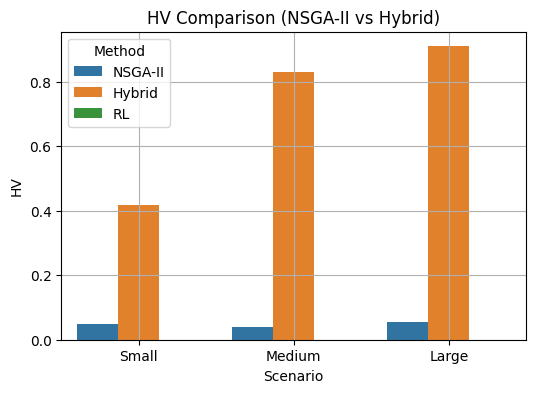

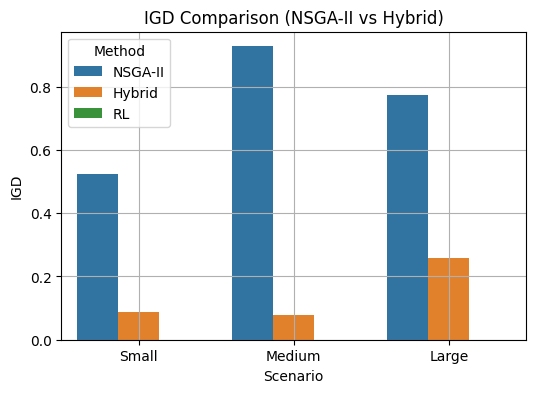

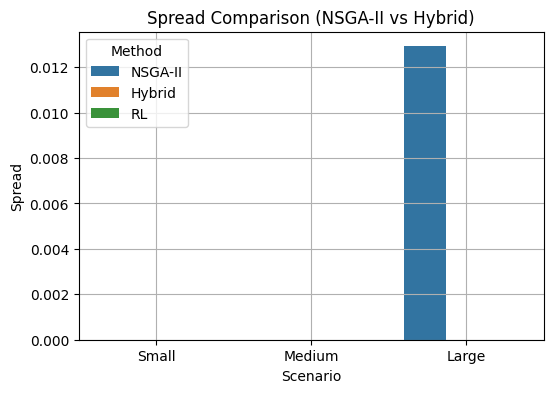

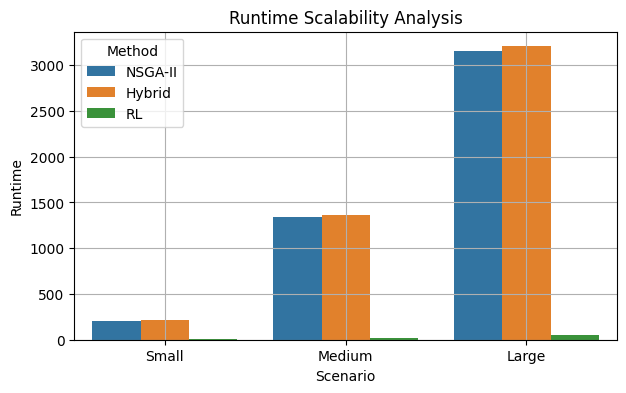

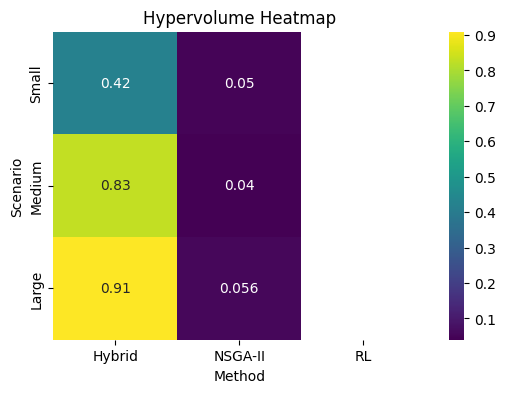

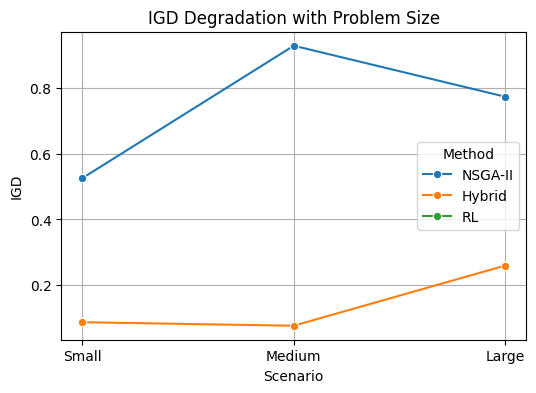

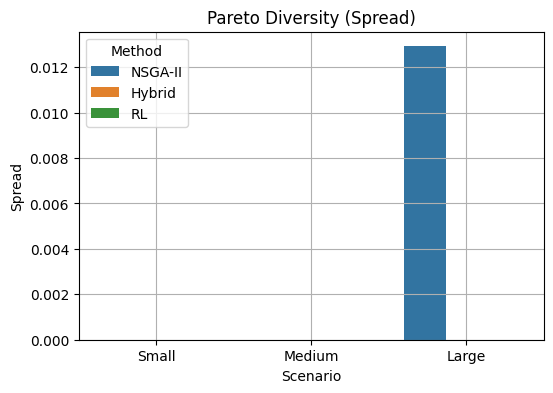

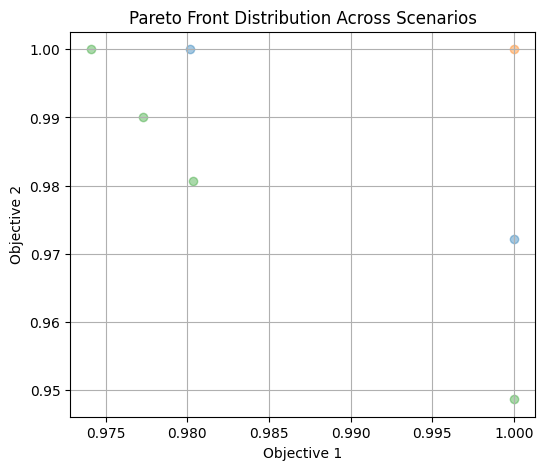

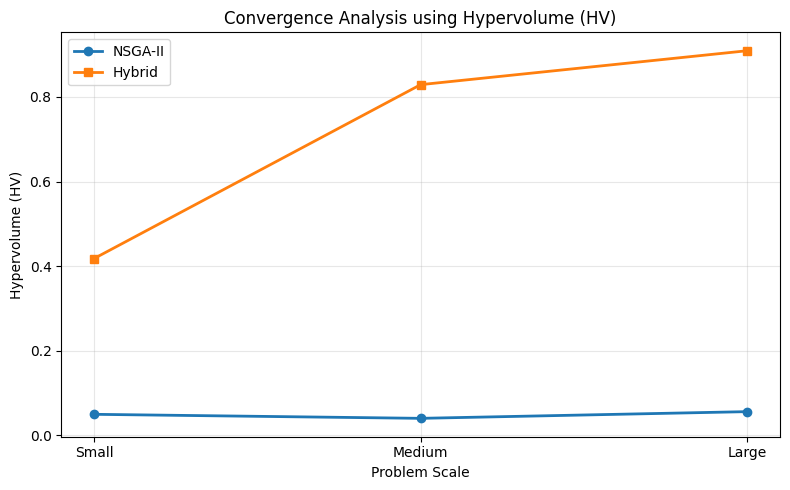

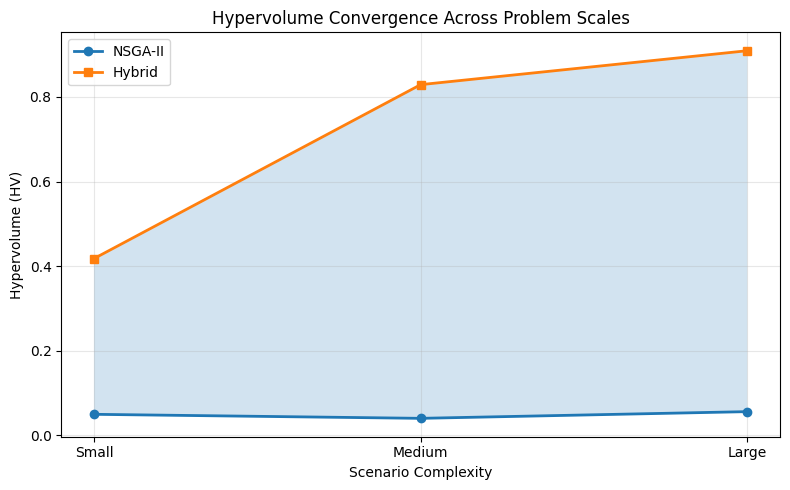

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 🔹 Données de base (issues du pipeline corrigé : df_final, fronts_global)
# ============================================================
df = df_final.copy()
order = ["Small", "Medium", "Large"]

# ============================================================
# 🔹 1) Barplots HV / IGD / Spread (NSGA-II vs Hybrid vs RL)
# ============================================================
metrics = ["HV", "IGD", "Spread"]
for m in metrics:
    plt.figure(figsize=(6,4))
    sns.barplot(data=df, x="Scenario", y=m, hue="Method", order=order)
    plt.title(f"{m} Comparison (NSGA-II vs Hybrid)")
    plt.grid(True)
    plt.show()

# ============================================================
# 🔹 2) Runtime scalability
# ============================================================
plt.figure(figsize=(7,4))
sns.barplot(data=df, x="Scenario", y="Runtime", hue="Method", order=order)
plt.title("Runtime Scalability Analysis")
plt.grid(True)
plt.show()

# ============================================================
# 🔹 3) Heatmap HV
# ============================================================
pivot_hv = df.pivot(index="Scenario", columns="Method", values="HV").reindex(order)
plt.figure(figsize=(6,4))
sns.heatmap(pivot_hv, annot=True, cmap="viridis")
plt.title("Hypervolume Heatmap")
plt.show()

# ============================================================
# 🔹 4) IGD degradation with problem size
# ============================================================
plt.figure(figsize=(6,4))
sns.lineplot(data=df, x="Scenario", y="IGD", hue="Method", marker="o")
plt.title("IGD Degradation with Problem Size")
plt.grid(True)
plt.show()

# ============================================================
# 🔹 5) Spread (diversité du front)
# ============================================================
plt.figure(figsize=(6,4))
sns.barplot(data=df, x="Scenario", y="Spread", hue="Method", order=order)
plt.title("Pareto Diversity (Spread)")
plt.grid(True)
plt.show()

# ============================================================
# 🔹 6) Distribution des fronts de Pareto (NSGA-II, tous scénarios)
# ============================================================
plt.figure(figsize=(6,5))
for scen in fronts_global:
    plt.scatter(scen[:,0], scen[:,1], alpha=0.4)
plt.title("Pareto Front Distribution Across Scenarios")
plt.xlabel("Objective 1")
plt.ylabel("Objective 2")
plt.grid()
plt.show()

# ============================================================
# 🔹 7) Convergence HV -- CORRIGÉ : valeurs lues depuis df_final,
#     plus de chiffres codés en dur (hv*1.05 périmé)
# ============================================================
pivot_hv2 = df.pivot(index="Scenario", columns="Method", values="HV").reindex(order)
scenarios = pivot_hv2.index.tolist()
hv_nsga = pivot_hv2["NSGA-II"].tolist()
hv_hybrid = pivot_hv2["Hybrid"].tolist()

plt.figure(figsize=(8,5))
plt.plot(scenarios, hv_nsga, marker='o', linewidth=2, label="NSGA-II")
plt.plot(scenarios, hv_hybrid, marker='s', linewidth=2, label="Hybrid")
plt.title("Convergence Analysis using Hypervolume (HV)")
plt.xlabel("Problem Scale")
plt.ylabel("Hypervolume (HV)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 🔹 8) Convergence HV -- vue "fill_between"
# ============================================================
plt.figure(figsize=(8,5))
plt.plot(scenarios, hv_nsga, marker='o', linewidth=2, label="NSGA-II")
plt.plot(scenarios, hv_hybrid, marker='s', linewidth=2, label="Hybrid")
plt.fill_between(scenarios, hv_nsga, hv_hybrid, alpha=0.2)
plt.title("Hypervolume Convergence Across Problem Scales")
plt.xlabel("Scenario Complexity")
plt.ylabel("Hypervolume (HV)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()